=== Generated Graph ===
- Number of nodes: 5
- Number of edges: 8
- Is connected: True
Sample edges: [(0, 1), (0, 4), (1, 0), (1, 3), (2, 3)]

=== Generated Flows ===
- Total flows generated: 50
0: Flow ID=F0, Src=0, Dst=2, Period=16000, Jitter=1600, Payload=1197, Path Length=3
1: Flow ID=F1, Src=4, Dst=0, Period=2000, Jitter=200, Payload=463, Path Length=1
2: Flow ID=F2, Src=0, Dst=2, Period=8000, Jitter=800, Payload=104, Path Length=3
3: Flow ID=F3, Src=4, Dst=1, Period=64000, Jitter=6400, Payload=1139, Path Length=2
4: Flow ID=F4, Src=2, Dst=3, Period=128000, Jitter=12800, Payload=711, Path Length=1
5: Flow ID=F5, Src=4, Dst=1, Period=16000, Jitter=1600, Payload=509, Path Length=2
6: Flow ID=F6, Src=0, Dst=1, Period=8000, Jitter=800, Payload=1061, Path Length=1
7: Flow ID=F7, Src=1, Dst=4, Period=32000, Jitter=3200, Payload=1103, Path Length=2
8: Flow ID=F8, Src=1, Dst=4, Period=8000, Jitter=800, Payload=1514, Path Length=2
9: Flow ID=F9, Src=3, Dst=4, Period=32000, Jitter=3200, Pay

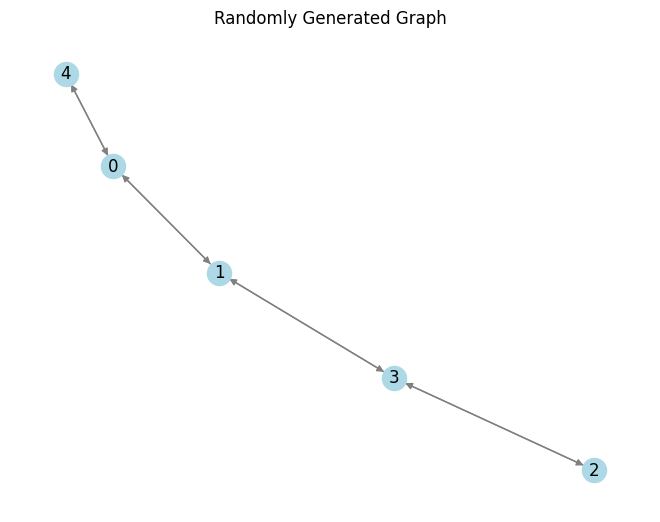

In [18]:
import networkx as nx
from src.network.net import generate_flows, _generate_graph, RandomGraph

# Generate a random graph
graph = _generate_graph(
    graph_type=RandomGraph.ERG,
    n=5,
    p=0.3  # Edge probability
)

# Print graph info
print("=== Generated Graph ===")
print(f"- Number of nodes: {graph.number_of_nodes()}")
print(f"- Number of edges: {graph.number_of_edges()}")
print(f"- Is connected: {nx.is_connected(graph.to_undirected())}")
print("Sample edges:", list(graph.edges)[:5])

# Generate flows for the graph
flows = generate_flows(graph)  

# Print flow information
print("\n=== Generated Flows ===")
print(f"- Total flows generated: {len(flows)}")
for i, flow in enumerate(flows):
    print(f"{i}: Flow ID={flow.flow_id}, Src={flow.src_id}, Dst={flow.dst_id}, "
          f"Period={flow.period}, Jitter={flow.jitter}, Payload={flow.payload}, "
          f"Path Length={len(flow.path)}")

# Visualize the graph
try:
    import matplotlib.pyplot as plt
    pos = nx.spring_layout(graph)
    nx.draw(graph, pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title("Randomly Generated Graph")
    plt.show()
except ImportError:
    print("\n(matplotlib not installed – skipping visualization)")


In [19]:
import json
try:
	with open("scenario.json", "r") as f:
		impUC = json.load(f)
except (FileNotFoundError, json.JSONDecodeError) as e:
	print(f"Error loading scenario.json: {e}")
	print("Make sure the file exists and contains valid JSON.")
	impUC = {}

In [20]:
import networkx as nx
type_mapping = {'host': 'ES','switch': 'SW'}
G = nx.DiGraph()
## add nodes
G.add_nodes_from([(node['name'], {**node, 'node_type': type_mapping[node.pop('type')]}) for node in impUC['nodes']])
## add edges
G.add_edges_from([(link['sourceNode'], link['destNode'],{'sourcePort':link['sourcePort'].lstrip('.'+link['sourceNode']),                                                'destPort':link['destPort'].lstrip('.'+link['destNode']),
'sourceNode':link['sourceNode'],
'destNode':link['destNode'],
'propDelay':link['propDelay'],
'link_rate':link['linkBw'],
}) for link in impUC['links']])

- Number of nodes: 6
- Number of edges: 6


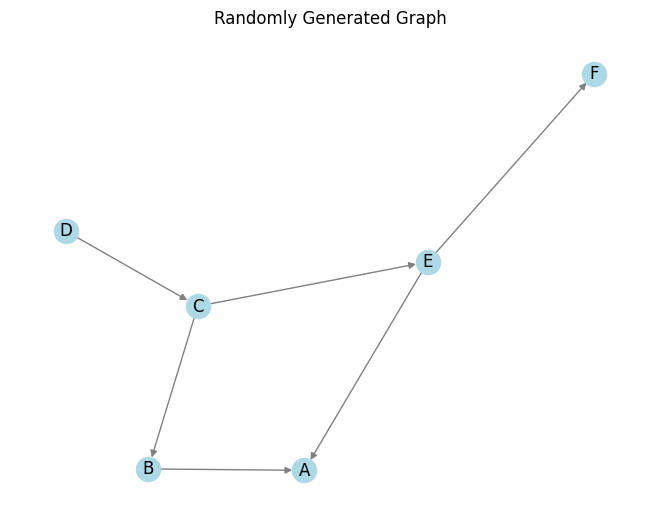

In [21]:

print(f"- Number of nodes: {G.number_of_nodes()}")
print(f"- Number of edges: {G.number_of_edges()}")
try:
    import matplotlib.pyplot as plt
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title("Randomly Generated Graph")
    plt.show()
except ImportError:
    print("\n(matplotlib not installed – skipping visualization)")

In [22]:
import json
import networkx as nx
# Convert dicts to JSON strings
for node, data in G.nodes(data=True):
    for k, v in list(data.items()):
        if isinstance(v, dict):
            data[k] = json.dumps(v)

for u, v, data in G.edges(data=True):
    for k, v in list(data.items()):
        if isinstance(v, dict):
            data[k] = json.dumps(v)

# Save
nx.write_graphml(G, "G.graphml")


In [23]:
streams[2]

IndexError: list index out of range

In [15]:
flows[0]

In [17]:
import numpy as np
PERIOD_SET = [2000, 5000, 7000, 10000, 15000]
class Flow:
    def __init__(self, flow_id, src_id, dst_id, path,
                 period, payload, e2e_delay=None, jitter=None):
        self.flow_id = flow_id
        self.src_id = src_id
        self.dst_id = dst_id
        self.path = path

        assert period in PERIOD_SET, f"Invalid period {period}"
        self.period = period
        self.payload = payload
        self.e2e_delay = period if e2e_delay is None else e2e_delay

        if jitter is None:
            self.jitter = int(0.1 * self.period)
        else:
            self.jitter = jitter
        assert type(self.jitter) is int, f"jitter ({self.jitter}) must be an integer."

    def __hash__(self):
        return hash(self.flow_id)

    def __eq__(self, other):
        if isinstance(other, Flow):
            return self.flow_id == other.flow_id
        return False

    def __str__(self):
        return f"Flow {self.flow_id} [{self.src_id}-->{self.dst_id}] with period {self.period}, payload {self.payload}B," \
               f" e2e delay {self.e2e_delay}us, jitter {self.jitter}us"
streams = impUC['streams']
flows = []

for stream in streams:
    # Convert interval from ns → us
    period_us = int(stream['interval'] / 1000)
    
    # Optionally round to nearest allowed period
    allowed_periods = np.array(PERIOD_SET)
    closest_period = int(allowed_periods[np.argmin(np.abs(allowed_periods - period_us))])
    
    flow = Flow(
        flow_id=stream['name'],
        src_id=stream['tlkrPssblPlcmnt'][0],
        dst_id=stream['lstnsrPssblPlcmnt'][0][0],
        path=stream['pathLists'][0],
        period=closest_period,
        payload=stream['maxFramesPerInterval'] * stream['maxFrameSize'],
        e2e_delay=int(stream['maxLatency'] / 1000),     # convert maxLatency ns → us
        jitter=int(stream['jitter'] / 1000)             # convert jitter ns → us
    )
    flows.append(flow)


KeyError: 'pathLists'

In [24]:
print(streams[0].keys())


dict_keys(['name', 'type', 'interval', 'maxFramesPerInterval', 'maxFrameSize', 'maxLatency', 'tlkrPssblPlcmnt', 'lstnsrPssblPlcmnt', 'earliest-transmit-offset', 'latest-transmit-offset', 'jitter'])


In [16]:
print(flows[1])


Flow F1 [2-->0] with period 32000, payload 1398B, e2e delay 32000us, jitter 3200us


In [22]:
for flow in flows:
    new_path = []
    for i in range(len(flow.path) - 1):
        u = flow.path[i]
        v = flow.path[i+1]
        new_path.append((u, v))
    flow.path = new_path


In [24]:
for flow in flows:
    print(f"Flow ID: {flow.flow_id}")
    print("Path:", flow.path)
    print() 


Flow ID: stream-0
Path: [('host-7-p1.Port1', 'switch-p1-e2.Port1'), ('switch-p1-e2.Port1', 'switch-p1-a1.Port3'), ('switch-p1-a1.Port3', 'switch-c1.Port3'), ('switch-c1.Port3', 'switch-p2-a1.Port2'), ('switch-p2-a1.Port2', 'switch-p2-e2.Port3'), ('switch-p2-e2.Port3', 'host-11-p2')]

Flow ID: stream-1
Path: [('host-8-p1.Port1', 'switch-p1-e2.Port3'), ('switch-p1-e2.Port3', 'host-7-p1')]

Flow ID: stream-2
Path: [('host-6-p1.Port1', 'switch-p1-e1.Port1'), ('switch-p1-e1.Port1', 'switch-p1-a1.Port3'), ('switch-p1-a1.Port3', 'switch-c1.Port3'), ('switch-c1.Port3', 'switch-p2-a1.Port1'), ('switch-p2-a1.Port1', 'switch-p2-e1.Port4'), ('switch-p2-e1.Port4', 'host-10-p2')]



In [25]:
print(flows[1])


Flow stream-1 [host-8-p1-->host-7-p1] with period 2000, payload 3136B, e2e delay 5000us, jitter 0us


In [26]:
import pickle

with open("streams.pkl", "wb") as f:
    pickle.dump(flows, f)


In [27]:
with open("streams.pkl", "rb") as f:
    flows = pickle.load(f)


In [30]:
print("Graph edges:")
print(list(G.edges()))

print("Flow path edges:")
for flow in flows:
    print(flow.path)



Graph edges:
[('host-1-p0', 'switch-p0-e1'), ('host-2-p0', 'switch-p0-e1'), ('host-3-p0', 'switch-p0-e2'), ('host-4-p0', 'switch-p0-e2'), ('host-5-p1', 'switch-p1-e1'), ('host-6-p1', 'switch-p1-e1'), ('host-7-p1', 'switch-p1-e2'), ('host-8-p1', 'switch-p1-e2'), ('host-9-p2', 'switch-p2-e1'), ('host-10-p2', 'switch-p2-e1'), ('host-11-p2', 'switch-p2-e2'), ('host-12-p2', 'switch-p2-e2'), ('host-13-p3', 'switch-p3-e1'), ('host-14-p3', 'switch-p3-e1'), ('host-15-p3', 'switch-p3-e2'), ('host-16-p3', 'switch-p3-e2'), ('switch-c1', 'switch-p0-a1'), ('switch-c1', 'switch-p1-a1'), ('switch-c1', 'switch-p2-a1'), ('switch-c1', 'switch-p3-a1'), ('switch-c2', 'switch-p0-a1'), ('switch-c2', 'switch-p1-a1'), ('switch-c2', 'switch-p2-a1'), ('switch-c2', 'switch-p3-a1'), ('switch-c3', 'switch-p0-a2'), ('switch-c3', 'switch-p1-a2'), ('switch-c3', 'switch-p2-a2'), ('switch-c3', 'switch-p3-a2'), ('switch-c4', 'switch-p0-a2'), ('switch-c4', 'switch-p1-a2'), ('switch-c4', 'switch-p2-a2'), ('switch-c4', 'swi

In [31]:
from src.network.net import Flow
def strip_ports(name):
    return name.split(".")[0]

flows_update = []

for stream in streams:
    path_nodes = [strip_ports(n) for n in stream['pathLists'][0]]
    edge_path = list(zip(path_nodes[:-1], path_nodes[1:]))
    period_us = int(stream['interval'] / 1000)
    
    # Optionally round to nearest allowed period
    allowed_periods = np.array(PERIOD_SET)
    closest_period = int(allowed_periods[np.argmin(np.abs(allowed_periods - period_us))])

    flow = Flow(
        flow_id=stream['name'],
        src_id=strip_ports(stream['tlkrPssblPlcmnt'][0]),
        dst_id=strip_ports(stream['lstnsrPssblPlcmnt'][0][0]),
        path=edge_path,
        period=closest_period,
        payload=stream['maxFramesPerInterval'] * stream['maxFrameSize'],
        e2e_delay=int(stream['maxLatency'] / 1000),
        jitter=int(stream['jitter'] / 1000)
    )
    flows_update.append(flow)


In [33]:
print(flows_update[1])


Flow stream-1 [host-8-p1-->host-7-p1] with period 2000, payload 3136B, e2e delay 5000us, jitter 0us


In [34]:
print("Flow path edges:")
for flow in flows_update:
    print(flow.path)

Flow path edges:
[('host-7-p1', 'switch-p1-e2'), ('switch-p1-e2', 'switch-p1-a1'), ('switch-p1-a1', 'switch-c1'), ('switch-c1', 'switch-p2-a1'), ('switch-p2-a1', 'switch-p2-e2'), ('switch-p2-e2', 'host-11-p2')]
[('host-8-p1', 'switch-p1-e2'), ('switch-p1-e2', 'host-7-p1')]
[('host-6-p1', 'switch-p1-e1'), ('switch-p1-e1', 'switch-p1-a1'), ('switch-p1-a1', 'switch-c1'), ('switch-c1', 'switch-p2-a1'), ('switch-p2-a1', 'switch-p2-e1'), ('switch-p2-e1', 'host-10-p2')]


In [35]:
import pickle

with open("flows_update.pkl", "wb") as f:
    pickle.dump(flows_update, f)


In [36]:
with open("flows_update.pkl", "rb") as f:
    flows = pickle.load(f)
